# Performance Estimation Accuracy — Paper Figure

4×6 grid: rows = parallelism strategy, cols = batch size.
Each subfigure compares estimated vs measured RPS per instance type.

In [1]:
import json, glob, os, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

BASE_DIR = os.path.dirname(os.path.abspath("__file__"))
WORKLOAD = "in763-out232"
PRED_DIR = os.path.join(BASE_DIR, "..", "trtllm", "llama3-70b", WORKLOAD, "predicted")
MEAS_ROOT = os.path.join(BASE_DIR, "..", "trtllm", "llama3-70b", WORKLOAD, "measured")
FIG_DIR = BASE_DIR  # current ./ dir
os.makedirs(FIG_DIR, exist_ok=True)

EXCLUDE_INSTANCES = ["p4d.24xlarge"]
BATCH_SIZES = [1, 2, 4, 8, 16, 32]
STRATEGIES = [(1, 8), (2, 4), (4, 2), (8, 1)]  # (pp, tp)

INSTANCE_SHORT = {
    "g5.48xlarge": "A10G",
    "g6.48xlarge": "L4",
    "g6e.48xlarge": "L40S",
}
INSTANCE_ORDER = ["g5.48xlarge", "g6.48xlarge", "g6e.48xlarge"]

print(f"Predicted: {PRED_DIR}")
print(f"Measured: {MEAS_ROOT}")

Predicted: /home/ubuntu/ShuntServe/ArtifactEvaluation/ReferenceData/PerformanceEstimation/figures/../trtllm/llama3-70b/in763-out232/predicted
Measured: /home/ubuntu/ShuntServe/ArtifactEvaluation/ReferenceData/PerformanceEstimation/figures/../trtllm/llama3-70b/in763-out232/measured


In [2]:
# ── Data Loading ──

def parse_gptbench_log(filepath):
    metrics = {}
    with open(filepath) as f:
        for line in f:
            if "[BENCHMARK]" not in line: continue
            parts = line.replace("[BENCHMARK] ", "").strip()
            tokens = parts.rsplit(" ", 1)
            if len(tokens) != 2: continue
            key = re.sub(r'\(.*?\)', '', tokens[0]).strip()
            try: metrics[key] = float(tokens[1])
            except: pass
    return metrics

# Predicted
pred_rows = []
for f in sorted(glob.glob(os.path.join(PRED_DIR, "est_*.json"))):
    d = json.load(open(f))
    if not d.get("feasible"): continue
    inst = d["instance_type"]
    if inst in EXCLUDE_INSTANCES: continue
    for e in d.get("batch_sweep", []):
        pred_rows.append({
            "instance": inst, "tp": d["tp_size"], "pp": d["pp_size"],
            "batch": e["batch_size"], "rps_est": e["throughput_rps"],
        })
pred_df = pd.DataFrame(pred_rows)

# Measured
meas_rows = []
for inst_dir in sorted(os.listdir(MEAS_ROOT)):
    log_dir = os.path.join(MEAS_ROOT, inst_dir, "gptBench", "log")
    if not os.path.isdir(log_dir): continue
    inst_name = inst_dir.replace("-", ".")
    if inst_name in EXCLUDE_INSTANCES: continue
    for fp in sorted(glob.glob(os.path.join(log_dir, "trtllm_*.log"))):
        m = re.match(r"trtllm_tp(\d+)_pp(\d+)_bs(\d+)\.log", os.path.basename(fp))
        if not m: continue
        metrics = parse_gptbench_log(fp)
        if not metrics or metrics.get("num_samples", 0) == 0: continue
        ns = int(metrics["num_samples"])
        total = metrics.get("total_latency", 0)
        meas_rows.append({
            "instance": inst_name, "tp": int(m.group(1)), "pp": int(m.group(2)),
            "batch": int(m.group(3)),
            "rps_meas": ns / (total / 1000) if total > 0 else 0,
        })
meas_df = pd.DataFrame(meas_rows)

merged = pd.merge(pred_df, meas_df, on=["instance", "tp", "pp", "batch"])
print(f"Merged: {len(merged)} data points")
print(f"Instances: {sorted(merged['instance'].unique())}")
print(f"Strategies (pp,tp): {sorted(merged.groupby(['pp','tp']).groups.keys())}")
print(f"Batch sizes: {sorted(merged['batch'].unique())}")

Merged: 62 data points
Instances: ['g5.48xlarge', 'g6.48xlarge', 'g6e.48xlarge']
Strategies (pp,tp): [(1, 8), (2, 4), (4, 2), (8, 1)]
Batch sizes: [np.int64(1), np.int64(2), np.int64(4), np.int64(8), np.int64(16), np.int64(32), np.int64(64), np.int64(128)]


Saved to /home/ubuntu/ShuntServe/ArtifactEvaluation/ReferenceData/PerformanceEstimation/figures/estimation_accuracy.{pdf,png}


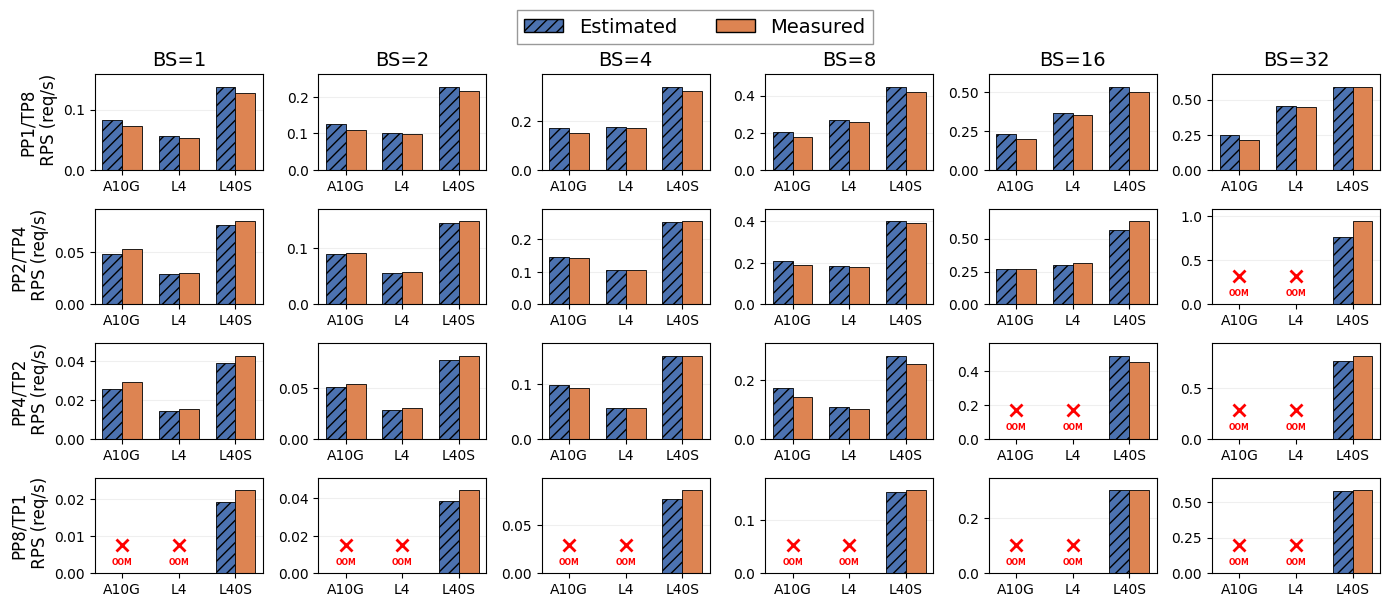

In [3]:
# ── Figure: 4 rows × 6 cols ──

# ============================================================
# Font size / weight variables — adjust these to tune the figure
# ============================================================
TITLE_FONTSIZE = 14          # BS=N column titles
TITLE_FONTWEIGHT = "normal"  # was "bold"; use "normal", "light", "medium", "bold", etc.

YLABEL_FONTSIZE = 12        # PP/TP row labels
YLABEL_FONTWEIGHT = "normal" # was "bold"

XTICK_FONTSIZE = 10         # instance type labels on x-axis
XTICK_ROTATION = 0        # rotation angle for x-axis labels (degrees)
YTICK_FONTSIZE = 10           # numeric tick labels on y-axis

LEGEND_FONTSIZE = 14         # legend text
OOM_FONTSIZE = 5.5           # "OOM" annotation text
# ============================================================

C_EST = "#4C72B0"
C_MEAS = "#DD8452"
HATCH_EST = "///"
HATCH_MEAS = ""

n_rows = len(STRATEGIES)
n_cols = len(BATCH_SIZES)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 6), squeeze=False)

for row_idx, (pp, tp) in enumerate(STRATEGIES):
    for col_idx, bs in enumerate(BATCH_SIZES):
        ax = axes[row_idx][col_idx]
        sub = merged[(merged["pp"] == pp) & (merged["tp"] == tp) & (merged["batch"] == bs)]
        x = np.arange(len(INSTANCE_ORDER))
        w = 0.35
        xlabels = [INSTANCE_SHORT.get(i, i) for i in INSTANCE_ORDER]

        est_vals, meas_vals, missing = [], [], []
        for idx, inst in enumerate(INSTANCE_ORDER):
            row_data = sub[sub["instance"] == inst]
            if row_data.empty:
                est_vals.append(0); meas_vals.append(0); missing.append(idx)
            else:
                est_vals.append(row_data["rps_est"].values[0])
                meas_vals.append(row_data["rps_meas"].values[0])

        ax.bar(x - w/2, est_vals, w, color=C_EST, edgecolor="black", linewidth=0.6, hatch=HATCH_EST)
        ax.bar(x + w/2, meas_vals, w, color=C_MEAS, edgecolor="black", linewidth=0.6, hatch=HATCH_MEAS)

        ax.set_ylim(bottom=0)
        # Auto y-lim per subfig, then add headroom
        if not sub.empty:
            local_max = max(max(est_vals), max(meas_vals))
            ax.set_ylim(0, local_max * 1.15)

        # Mark missing data
        ymax = ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1
        for idx in missing:
            ax.plot(x[idx], ymax * 0.3, marker="x", markersize=8, color="red", markeredgewidth=2, zorder=5)
            ax.text(x[idx], ymax * 0.12, "OOM", fontsize=OOM_FONTSIZE, ha="center", va="center",
                    color="red", fontweight="bold")

        ax.set_xticks(x)
        ax.set_xticklabels(xlabels, fontsize=XTICK_FONTSIZE, rotation=XTICK_ROTATION, ha="center")
        if col_idx == 0:
            ax.set_ylabel(f"PP{pp}/TP{tp}\n RPS (req/s)", fontsize=YLABEL_FONTSIZE, fontweight=YLABEL_FONTWEIGHT)
        if row_idx == 0:
            ax.set_title(f"BS={bs}", fontsize=TITLE_FONTSIZE, fontweight=TITLE_FONTWEIGHT)
        ax.tick_params(axis="y", labelsize=YTICK_FONTSIZE)
        ax.grid(True, alpha=0.2, axis="y")
        ax.set_axisbelow(True)

legend_elements = [
    Patch(facecolor=C_EST, edgecolor="black", hatch=HATCH_EST, label="Estimated"),
    Patch(facecolor=C_MEAS, edgecolor="black", hatch=HATCH_MEAS, label="Measured"),
]
fig.legend(handles=legend_elements, loc="upper center", ncol=2, frameon=True, fontsize=LEGEND_FONTSIZE,
    bbox_to_anchor=(0.5, 1.02), edgecolor="gray", fancybox=False)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(os.path.join(FIG_DIR, "estimation_accuracy.pdf"), bbox_inches="tight", dpi=600)
fig.savefig(os.path.join(FIG_DIR, "estimation_accuracy.png"), bbox_inches="tight", dpi=600)
print(f"Saved to {FIG_DIR}/estimation_accuracy.{{pdf,png}}")
plt.show()

In [4]:
# ── Load Latency Data ──

# Predicted latency (convert ms → s)
pred_lat_rows = []
for f in sorted(glob.glob(os.path.join(PRED_DIR, "est_*.json"))):
    d = json.load(open(f))
    if not d.get("feasible"): continue
    inst = d["instance_type"]
    if inst in EXCLUDE_INSTANCES: continue
    for e in d.get("batch_sweep", []):
        pred_lat_rows.append({
            "instance": inst, "tp": d["tp_size"], "pp": d["pp_size"],
            "batch": e["batch_size"], "lat_est": e["batch_latency_ms"] / 1000,
        })
pred_lat_df = pd.DataFrame(pred_lat_rows)

# Measured latency (avg_sequence_latency, convert ms → s)
meas_lat_rows = []
for inst_dir in sorted(os.listdir(MEAS_ROOT)):
    log_dir = os.path.join(MEAS_ROOT, inst_dir, "gptBench", "log")
    if not os.path.isdir(log_dir): continue
    inst_name = inst_dir.replace("-", ".")
    if inst_name in EXCLUDE_INSTANCES: continue
    for fp in sorted(glob.glob(os.path.join(log_dir, "trtllm_*.log"))):
        m = re.match(r"trtllm_tp(\d+)_pp(\d+)_bs(\d+)\.log", os.path.basename(fp))
        if not m: continue
        metrics = parse_gptbench_log(fp)
        if not metrics or metrics.get("num_samples", 0) == 0: continue
        avg_lat = metrics.get("avg_sequence_latency", 0)
        if avg_lat <= 0: continue
        meas_lat_rows.append({
            "instance": inst_name, "tp": int(m.group(1)), "pp": int(m.group(2)),
            "batch": int(m.group(3)), "lat_meas": avg_lat / 1000,
        })
meas_lat_df = pd.DataFrame(meas_lat_rows)

merged_lat = pd.merge(pred_lat_df, meas_lat_df, on=["instance", "tp", "pp", "batch"])
print(f"Latency merged: {len(merged_lat)} data points")

Latency merged: 62 data points


Saved to /home/ubuntu/ShuntServe/ArtifactEvaluation/ReferenceData/PerformanceEstimation/figures/estimation_accuracy_latency.{pdf,png}


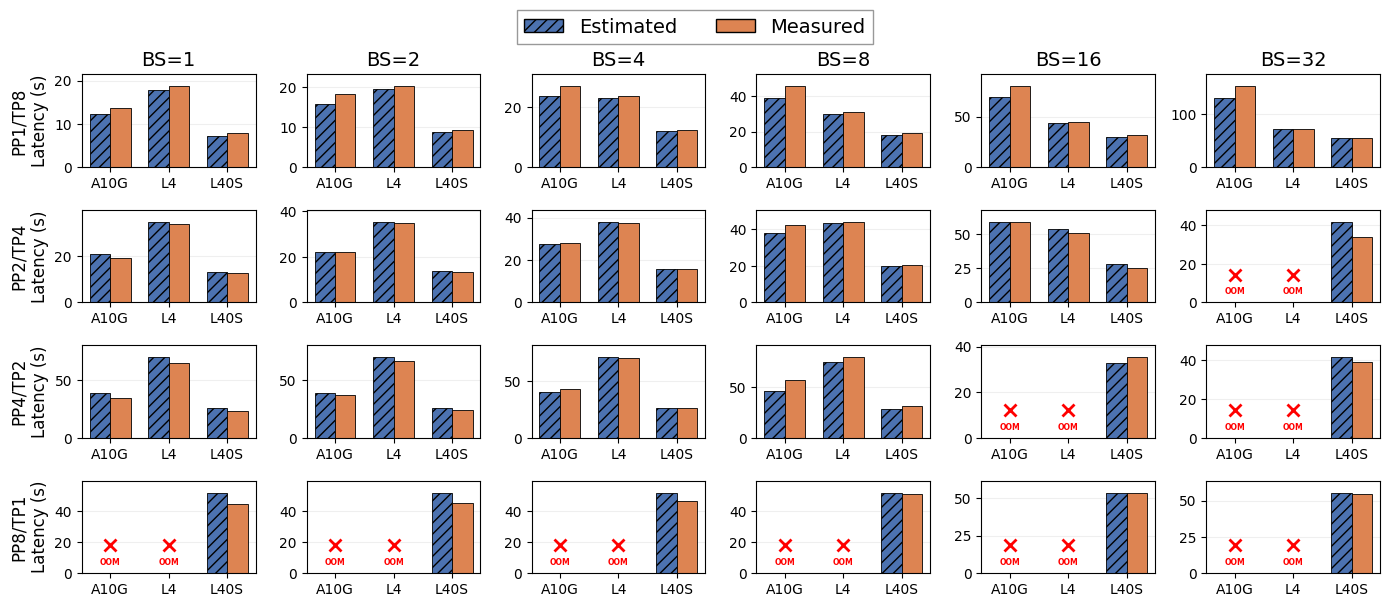

In [5]:
# ── Latency Figure: 4 rows × 6 cols ──

n_rows = len(STRATEGIES)
n_cols = len(BATCH_SIZES)
fig_lat, axes_lat = plt.subplots(n_rows, n_cols, figsize=(14, 6), squeeze=False)

for row_idx, (pp, tp) in enumerate(STRATEGIES):
    for col_idx, bs in enumerate(BATCH_SIZES):
        ax = axes_lat[row_idx][col_idx]
        sub = merged_lat[(merged_lat["pp"] == pp) & (merged_lat["tp"] == tp) & (merged_lat["batch"] == bs)]
        x = np.arange(len(INSTANCE_ORDER))
        w = 0.35
        xlabels = [INSTANCE_SHORT.get(i, i) for i in INSTANCE_ORDER]

        est_vals, meas_vals, missing = [], [], []
        for idx, inst in enumerate(INSTANCE_ORDER):
            row_data = sub[sub["instance"] == inst]
            if row_data.empty:
                est_vals.append(0); meas_vals.append(0); missing.append(idx)
            else:
                est_vals.append(row_data["lat_est"].values[0])
                meas_vals.append(row_data["lat_meas"].values[0])

        ax.bar(x - w/2, est_vals, w, color=C_EST, edgecolor="black", linewidth=0.6, hatch=HATCH_EST)
        ax.bar(x + w/2, meas_vals, w, color=C_MEAS, edgecolor="black", linewidth=0.6, hatch=HATCH_MEAS)

        ax.set_ylim(bottom=0)
        if not sub.empty:
            local_max = max(max(est_vals), max(meas_vals))
            ax.set_ylim(0, local_max * 1.15)

        # Mark missing data
        ymax = ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1
        for idx in missing:
            ax.plot(x[idx], ymax * 0.3, marker="x", markersize=8, color="red", markeredgewidth=2, zorder=5)
            ax.text(x[idx], ymax * 0.12, "OOM", fontsize=OOM_FONTSIZE, ha="center", va="center",
                    color="red", fontweight="bold")

        ax.set_xticks(x)
        ax.set_xticklabels(xlabels, fontsize=XTICK_FONTSIZE, rotation=XTICK_ROTATION, ha="center")
        if col_idx == 0:
            ax.set_ylabel(f"PP{pp}/TP{tp}\nLatency (s)", fontsize=YLABEL_FONTSIZE, fontweight=YLABEL_FONTWEIGHT)
        if row_idx == 0:
            ax.set_title(f"BS={bs}", fontsize=TITLE_FONTSIZE, fontweight=TITLE_FONTWEIGHT)
        ax.tick_params(axis="y", labelsize=YTICK_FONTSIZE)
        ax.grid(True, alpha=0.2, axis="y")
        ax.set_axisbelow(True)

legend_elements = [
    Patch(facecolor=C_EST, edgecolor="black", hatch=HATCH_EST, label="Estimated"),
    Patch(facecolor=C_MEAS, edgecolor="black", hatch=HATCH_MEAS, label="Measured"),
]
fig_lat.legend(handles=legend_elements, loc="upper center", ncol=2, frameon=True, fontsize=LEGEND_FONTSIZE,
    bbox_to_anchor=(0.5, 1.02), edgecolor="gray", fancybox=False)
fig_lat.tight_layout(rect=[0, 0, 1, 0.96])
fig_lat.savefig(os.path.join(FIG_DIR, "estimation_accuracy_latency.pdf"), bbox_inches="tight", dpi=600)
fig_lat.savefig(os.path.join(FIG_DIR, "estimation_accuracy_latency.png"), bbox_inches="tight", dpi=600)
print(f"Saved to {FIG_DIR}/estimation_accuracy_latency.{{pdf,png}}")
plt.show()

In [6]:
# ── Latency MAPE Table: Full Detail (PP/TP × BS × Device) ──

filtered_lat = merged_lat[merged_lat["batch"].isin(BATCH_SIZES)].copy()
filtered_lat["ape"] = (filtered_lat["lat_est"] - filtered_lat["lat_meas"]).abs() / filtered_lat["lat_meas"] * 100
filtered_lat["strategy"] = filtered_lat.apply(lambda r: f"PP{r['pp']}/TP{r['tp']}", axis=1)
filtered_lat["device"] = filtered_lat["instance"].map(INSTANCE_SHORT)

strat_order = [f"PP{pp}/TP{tp}" for pp, tp in STRATEGIES]
dev_order = [INSTANCE_SHORT[i] for i in INSTANCE_ORDER]

detail_lat = filtered_lat.pivot_table(index=["strategy", "batch"], columns="device", values="ape", aggfunc="mean")
detail_lat = detail_lat[dev_order]
detail_lat.index.names = ["Strategy", "Batch Size"]
detail_lat = detail_lat.reindex(strat_order, level="Strategy")

print("Latency MAPE (%) — Full Detail")
print("=" * 55)
display(detail_lat.round(2))

Latency MAPE (%) — Full Detail


device                A10G    L4   L40S
Strategy Batch Size                    
PP1/TP8  1           10.66  4.28   7.12
         2           13.34  3.56   4.95
         4           11.94  2.59   5.20
         8           14.78  3.76   5.82
         16          13.52  3.14   5.95
         32          14.23  0.85   0.03
PP2/TP4  1            9.88  3.35   5.00
         2            1.43  1.57   2.08
         4            2.50  1.37   1.47
         8           10.52  1.94   2.13
         16           0.67  6.09  12.07
         32            NaN   NaN  23.72
PP4/TP2  1           12.33  7.49   9.25
         2            5.86  5.18   5.73
         4            4.68  1.12   0.42
         8           18.73  6.02  10.14
         16            NaN   NaN   7.43
         32            NaN   NaN   6.40
PP8/TP1  1             NaN   NaN  16.10
         2             NaN   NaN  14.54
         4             NaN   NaN  11.47
         8             NaN   NaN   1.87
         16            NaN   NaN   0.25
         32            NaN   NaN   1.24

In [7]:
# ── Latency MAPE Aggregated Statistics ──

def min_max_info_lat(group_df, group_col):
    idx_min = group_df["ape"].idxmin()
    idx_max = group_df["ape"].idxmax()
    r_min = group_df.loc[idx_min]
    r_max = group_df.loc[idx_max]
    def desc(r):
        parts = []
        if group_col != "strategy":
            parts.append(f"PP{int(r['pp'])}/TP{int(r['tp'])}")
        if group_col != "batch":
            parts.append(f"BS={int(r['batch'])}")
        if group_col != "device":
            parts.append(r["device"])
        return ", ".join(parts)
    return r_min["ape"], desc(r_min), r_max["ape"], desc(r_max)

print("▶ Latency MAPE by Strategy (PP/TP)")
for s in strat_order:
    sub = filtered_lat[filtered_lat["strategy"] == s]
    if sub.empty: continue
    mn, mn_d, mx, mx_d = min_max_info_lat(sub, "strategy")
    print(f"  {s:>9s} : {sub['ape'].mean():.2f}%  (min {mn:.2f}% @ {mn_d}, max {mx:.2f}% @ {mx_d})")

print("\n▶ Latency MAPE by Batch Size")
bs_mape = filtered_lat.groupby("batch")["ape"].mean()
for bs in BATCH_SIZES:
    sub = filtered_lat[filtered_lat["batch"] == bs]
    if sub.empty: continue
    mn, mn_d, mx, mx_d = min_max_info_lat(sub, "batch")
    print(f"  BS={bs:<3d}    : {sub['ape'].mean():.2f}%  (min {mn:.2f}% @ {mn_d}, max {mx:.2f}% @ {mx_d})")

print("\n▶ Latency MAPE by Device")
for d in dev_order:
    sub = filtered_lat[filtered_lat["device"] == d]
    if sub.empty: continue
    mn, mn_d, mx, mx_d = min_max_info_lat(sub, "device")
    print(f"  {d:>5s}     : {sub['ape'].mean():.2f}%  (min {mn:.2f}% @ {mn_d}, max {mx:.2f}% @ {mx_d})")

mn_all, mn_all_d, mx_all, mx_all_d = min_max_info_lat(filtered_lat, "")
print("\n" + "=" * 70)
print(f"  Total Latency MAPE (all {len(filtered_lat)} points) : {filtered_lat['ape'].mean():.2f}%")
print(f"  Min: {mn_all:.2f}% @ {mn_all_d}")
print(f"  Max: {mx_all:.2f}% @ {mx_all_d}")
print("=" * 70)

▶ Latency MAPE by Strategy (PP/TP)
    PP1/TP8 : 6.98%  (min 0.03% @ BS=32, L40S, max 14.78% @ BS=8, A10G)
    PP2/TP4 : 5.36%  (min 0.67% @ BS=16, A10G, max 23.72% @ BS=32, L40S)
    PP4/TP2 : 7.20%  (min 0.42% @ BS=4, L40S, max 18.73% @ BS=8, A10G)
    PP8/TP1 : 7.58%  (min 0.25% @ BS=16, L40S, max 16.10% @ BS=1, L40S)

▶ Latency MAPE by Batch Size
  BS=1      : 8.55%  (min 3.35% @ PP2/TP4, L4, max 16.10% @ PP8/TP1, L40S)
  BS=2      : 5.82%  (min 1.43% @ PP2/TP4, A10G, max 14.54% @ PP8/TP1, L40S)
  BS=4      : 4.28%  (min 0.42% @ PP4/TP2, L40S, max 11.94% @ PP1/TP8, A10G)
  BS=8      : 7.57%  (min 1.87% @ PP8/TP1, L40S, max 18.73% @ PP4/TP2, A10G)
  BS=16     : 6.14%  (min 0.25% @ PP8/TP1, L40S, max 13.52% @ PP1/TP8, A10G)
  BS=32     : 7.74%  (min 0.03% @ PP1/TP8, L40S, max 23.72% @ PP2/TP4, L40S)

▶ Latency MAPE by Device
   A10G     : 9.67%  (min 0.67% @ PP2/TP4, BS=16, max 18.73% @ PP4/TP2, BS=8)
     L4     : 3.49%  (min 0.85% @ PP1/TP8, BS=32, max 7.49% @ PP4/TP2, BS=1)
   L40

In [8]:
# ── MAPE Table: Full Detail (PP/TP × BS × Device) ──

filtered = merged[merged["batch"].isin(BATCH_SIZES)].copy()
filtered["ape"] = (filtered["rps_est"] - filtered["rps_meas"]).abs() / filtered["rps_meas"] * 100
filtered["strategy"] = filtered.apply(lambda r: f"PP{r['pp']}/TP{r['tp']}", axis=1)
filtered["device"] = filtered["instance"].map(INSTANCE_SHORT)

# Build pivot: rows = (Strategy, BS), cols = Device
strat_order = [f"PP{pp}/TP{tp}" for pp, tp in STRATEGIES]
dev_order = [INSTANCE_SHORT[i] for i in INSTANCE_ORDER]

detail = filtered.pivot_table(index=["strategy", "batch"], columns="device", values="ape", aggfunc="mean")
detail = detail[dev_order]
detail.index.names = ["Strategy", "Batch Size"]
detail = detail.reindex(strat_order, level="Strategy")

print("MAPE (%) — Full Detail")
print("=" * 55)
display(detail.round(2))

MAPE (%) — Full Detail


device                A10G    L4   L40S
Strategy Batch Size                    
PP1/TP8  1           11.93  4.47   7.67
         2           15.39  3.69   5.21
         4           13.56  2.66   5.49
         8           17.35  3.91   6.18
         16          15.69  3.37   6.42
         32          16.67  1.00   0.08
PP2/TP4  1            8.99  3.24   4.77
         2            1.41  1.55   2.04
         4            2.57  1.35   1.45
         8           11.75  1.98   2.18
         16           0.72  5.66  10.71
         32            NaN   NaN  19.10
PP4/TP2  1           10.98  6.97   8.47
         2            5.53  4.93   5.42
         4            4.91  1.10   0.43
         8           23.05  6.41  11.29
         16            NaN   NaN   8.17
         32            NaN   NaN   5.93
PP8/TP1  1             NaN   NaN  13.87
         2             NaN   NaN  12.70
         4             NaN   NaN  10.29
         8             NaN   NaN   1.84
         16            NaN   NaN   0.44
         32            NaN   NaN   1.12

In [9]:
# ── MAPE Aggregated Statistics ──

def min_max_info(group_df, group_col):
    """Return min/max APE rows with their full config description."""
    idx_min = group_df["ape"].idxmin()
    idx_max = group_df["ape"].idxmax()
    r_min = group_df.loc[idx_min]
    r_max = group_df.loc[idx_max]
    def desc(r):
        parts = []
        if group_col != "strategy":
            parts.append(f"PP{int(r['pp'])}/TP{int(r['tp'])}")
        if group_col != "batch":
            parts.append(f"BS={int(r['batch'])}")
        if group_col != "device":
            parts.append(r["device"])
        return ", ".join(parts)
    return r_min["ape"], desc(r_min), r_max["ape"], desc(r_max)

print("▶ MAPE by Strategy (PP/TP)")
for s in strat_order:
    sub = filtered[filtered["strategy"] == s]
    if sub.empty: continue
    mn, mn_d, mx, mx_d = min_max_info(sub, "strategy")
    print(f"  {s:>9s} : {sub['ape'].mean():.2f}%  (min {mn:.2f}% @ {mn_d}, max {mx:.2f}% @ {mx_d})")

print("\n▶ MAPE by Batch Size")
for bs in BATCH_SIZES:
    sub = filtered[filtered["batch"] == bs]
    if sub.empty: continue
    mn, mn_d, mx, mx_d = min_max_info(sub, "batch")
    print(f"  BS={bs:<3d}    : {sub['ape'].mean():.2f}%  (min {mn:.2f}% @ {mn_d}, max {mx:.2f}% @ {mx_d})")

print("\n▶ MAPE by Device")
for d in dev_order:
    sub = filtered[filtered["device"] == d]
    if sub.empty: continue
    mn, mn_d, mx, mx_d = min_max_info(sub, "device")
    print(f"  {d:>5s}     : {sub['ape'].mean():.2f}%  (min {mn:.2f}% @ {mn_d}, max {mx:.2f}% @ {mx_d})")

mn_all, mn_all_d, mx_all, mx_all_d = min_max_info(filtered, "")
print("\n" + "=" * 70)
print(f"  Total MAPE (all {len(filtered)} points) : {filtered['ape'].mean():.2f}%")
print(f"  Min: {mn_all:.2f}% @ {mn_all_d}")
print(f"  Max: {mx_all:.2f}% @ {mx_all_d}")
print("=" * 70)

▶ MAPE by Strategy (PP/TP)
    PP1/TP8 : 7.82%  (min 0.08% @ BS=32, L40S, max 17.35% @ BS=8, A10G)
    PP2/TP4 : 4.97%  (min 0.72% @ BS=16, A10G, max 19.10% @ BS=32, L40S)
    PP4/TP2 : 7.40%  (min 0.43% @ BS=4, L40S, max 23.05% @ BS=8, A10G)
    PP8/TP1 : 6.71%  (min 0.44% @ BS=16, L40S, max 13.87% @ BS=1, L40S)

▶ MAPE by Batch Size
  BS=1      : 8.13%  (min 3.24% @ PP2/TP4, L4, max 13.87% @ PP8/TP1, L40S)
  BS=2      : 5.79%  (min 1.41% @ PP2/TP4, A10G, max 15.39% @ PP1/TP8, A10G)
  BS=4      : 4.38%  (min 0.43% @ PP4/TP2, L40S, max 13.56% @ PP1/TP8, A10G)
  BS=8      : 8.59%  (min 1.84% @ PP8/TP1, L40S, max 23.05% @ PP4/TP2, A10G)
  BS=16     : 6.40%  (min 0.44% @ PP8/TP1, L40S, max 15.69% @ PP1/TP8, A10G)
  BS=32     : 7.32%  (min 0.08% @ PP1/TP8, L40S, max 19.10% @ PP2/TP4, L40S)

▶ MAPE by Device
   A10G     : 10.70%  (min 0.72% @ PP2/TP4, BS=16, max 23.05% @ PP4/TP2, BS=8)
     L4     : 3.49%  (min 1.00% @ PP1/TP8, BS=32, max 6.97% @ PP4/TP2, BS=1)
   L40S     : 6.30%  (min 0.0